# Clustering: Exercise

This exercise covers unsupervised customer segmentation on the **Mall Customers Dataset** (`datasets/mall_customers.csv`).

The dataset contains demographic and behavioural information for 200 mall customers.

| Column | Description |
|--------|-------------|
| `CustomerID` | Unique customer identifier |
| `Gender` | Customer gender (Male / Female) |
| `Age` | Customer age in years |
| `Annual Income (k$)` | Annual income in thousands of dollars |
| `Spending Score (1-100)` | Score assigned by the mall based on purchasing behaviour |

**Three K-Means clustering models are built using the following feature combinations:**

- **Model 1** - `Age` + `Spending Score`
- **Model 2** - `Annual Income` + `Spending Score`
- **Model 3** - `Age` + `Annual Income` + `Spending Score`

For each model, the **Elbow Method** is applied to determine the optimal number of clusters k, and the resulting segments are visualised via **2D scatter plots**. Model 3 is additionally shown as a **3D scatter plot** and its three 2D projections.

The cluster assignments from Model 3 are exported to `mall_customers_prediction.xlsx` with the customer ID and group label.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 0  # fixed seed for reproducibility

# Consistent colour palette across all scatter plots
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

## Step 1 - Data Loading

The dataset is loaded and inspected. No target column is present - this is an unsupervised learning task where the goal is to discover natural groupings in the data without predefined labels.

In [2]:
df = pd.read_csv('datasets/mall_customers.csv')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: (200, 5)
Missing values: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 2 - Exploratory Data Analysis

The distributions of all numeric features are examined to understand the range, spread, and shape of each variable. The scatter plot of `Annual Income` vs `Spending Score` gives an immediate visual impression of potential natural clusters - a pattern that the K-Means algorithm will later formalise.

In [3]:
print(df.describe())
print()
print('Gender distribution:')
print(df['Gender'].value_counts())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

Gender distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64


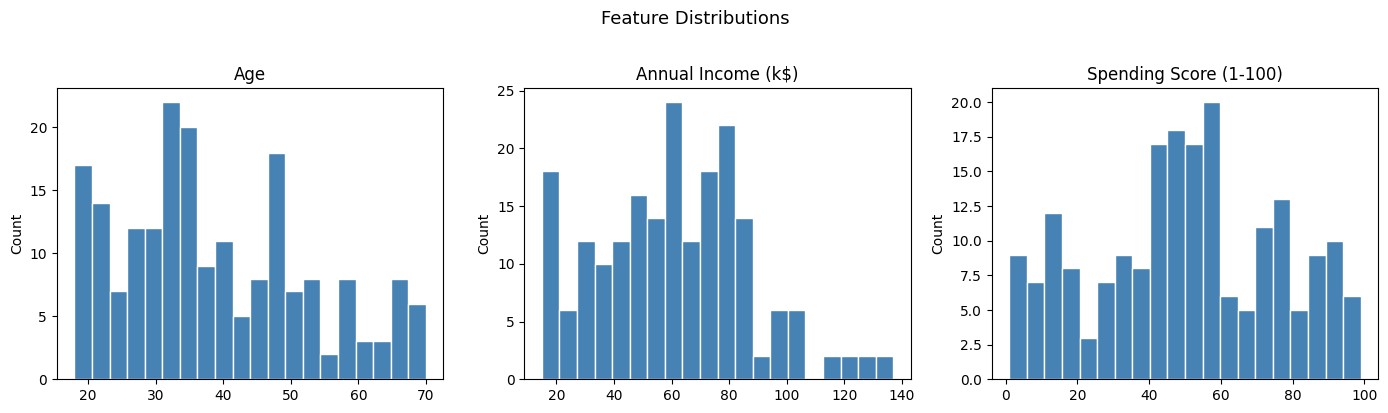

In [4]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

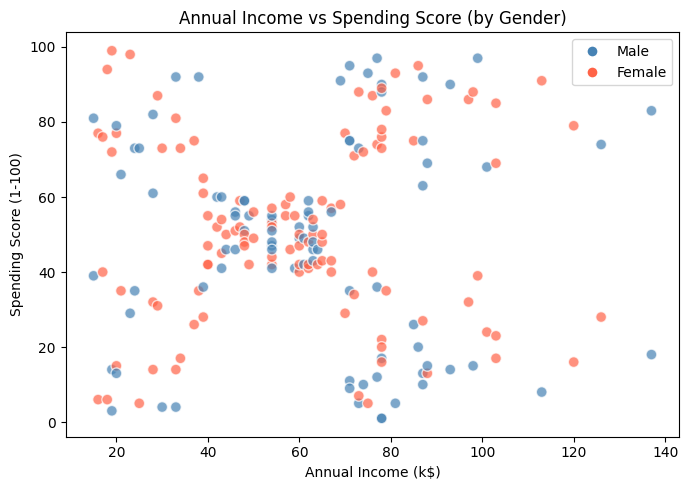

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = df['Gender'].map({'Male': 'steelblue', 'Female': 'tomato'})
ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
           c=colors, alpha=0.7, edgecolors='white', s=60)
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('Annual Income vs Spending Score (by Gender)')
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=8, label=l)
           for c, l in [('steelblue','Male'),('tomato','Female')]]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

## Helper Function - `run_elbow`

The **Elbow Method** fits K-Means for k = 1...10 and plots the **WCSS** (Within-Cluster Sum of Squares, also called inertia) against the number of clusters. WCSS always decreases as k increases; the optimal k is identified at the "elbow" - the point where additional clusters yield only marginal gains in compactness.

A reusable function is defined to avoid repeating the same loop for each model.

In [6]:
def run_elbow(X, title='Elbow Method', max_k=10):
    """Fit KMeans for k=1..max_k and plot the WCSS (inertia) curve."""
    wcss = []
    for k in range(1, max_k + 1):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_SEED)
        km.fit(X)
        wcss.append(km.inertia_)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, max_k + 1), wcss, marker='o', color='steelblue')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('WCSS (Inertia)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return wcss

## Step 3 - Model 1: Age + Spending Score

The first model clusters customers based on **age** and **spending behaviour**. This combination reveals whether different age groups exhibit distinct spending patterns - for example, young high-spenders vs older conservative shoppers.

The Elbow Method is applied first to identify the optimal k, then K-Means is fitted and the segments are visualised as a 2D scatter plot.

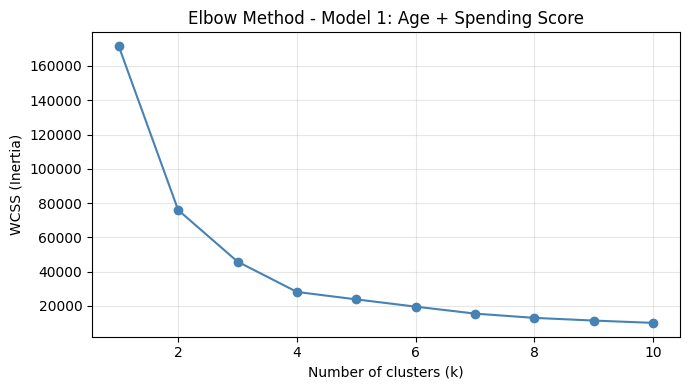

In [7]:
X1 = df[['Age', 'Spending Score (1-100)']].values

wcss1 = run_elbow(X1, title='Elbow Method - Model 1: Age + Spending Score')

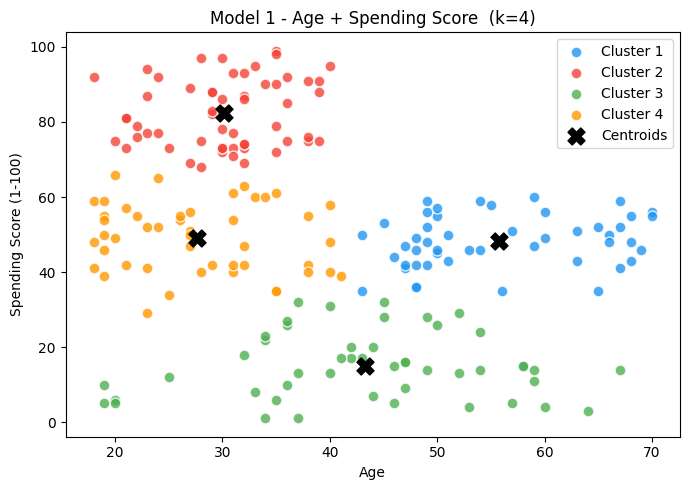

In [8]:
K1 = 4  # optimal k identified from the elbow above

km1 = KMeans(n_clusters=K1, init='k-means++', n_init=10, random_state=RANDOM_SEED)
labels1 = km1.fit_predict(X1)

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(K1):
    mask = labels1 == i
    ax.scatter(X1[mask, 0], X1[mask, 1],
               color=PALETTE[i], label=f'Cluster {i+1}',
               alpha=0.8, edgecolors='white', s=60)
# plot centroids
ax.scatter(km1.cluster_centers_[:, 0], km1.cluster_centers_[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroids')
ax.set_xlabel('Age')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title(f'Model 1 - Age + Spending Score  (k={K1})')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 - Model 2: Annual Income + Spending Score

The second model clusters customers based on **purchasing power** (annual income) and **spending behaviour**. This is the most commercially informative combination: it directly identifies segments such as high-income high-spenders (premium targets) and low-income high-spenders (impulse buyers).

The classical result on this dataset produces **5 distinct clusters**, often described as: budget-conscious, high-income savers, average shoppers, impulsive buyers, and premium customers.

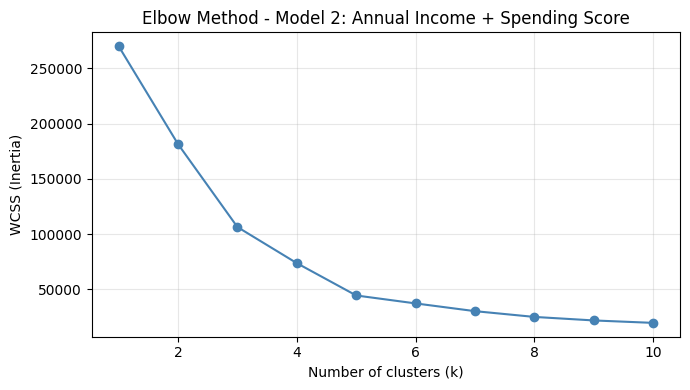

In [9]:
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

wcss2 = run_elbow(X2, title='Elbow Method - Model 2: Annual Income + Spending Score')

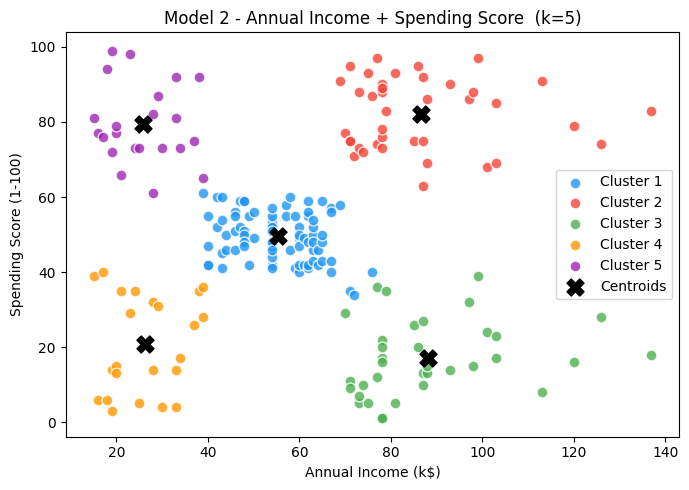

In [10]:
K2 = 5  # optimal k identified from the elbow above

km2 = KMeans(n_clusters=K2, init='k-means++', n_init=10, random_state=RANDOM_SEED)
labels2 = km2.fit_predict(X2)

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(K2):
    mask = labels2 == i
    ax.scatter(X2[mask, 0], X2[mask, 1],
               color=PALETTE[i], label=f'Cluster {i+1}',
               alpha=0.8, edgecolors='white', s=60)
ax.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroids')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title(f'Model 2 - Annual Income + Spending Score  (k={K2})')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 - Model 3: Age + Annual Income + Spending Score

The third model uses all three numeric features simultaneously, providing the most complete customer profile. With three dimensions, a **3D scatter plot** is used for the primary visualisation, and the three pairwise 2D projections are shown alongside to make the cluster structure readable from every angle.

Features are **standardised** before clustering: K-Means minimises Euclidean distance, so variables on larger scales (e.g. `Annual Income` ranging up to 137) would otherwise dominate the distance metric relative to `Spending Score` (max 99) and `Age` (max 70).

> **Note:** Standardisation is applied only to the model fitting. The scatter plots display the original (unscaled) values so that axes remain interpretable.

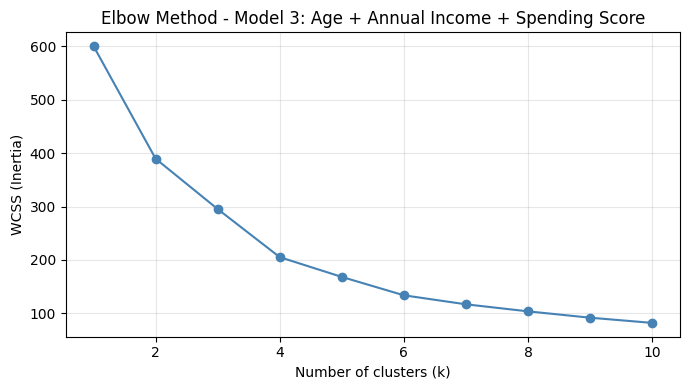

In [11]:
X3_raw = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

# Standardise before fitting (distance-based algorithm)
scaler = StandardScaler()
X3 = scaler.fit_transform(X3_raw)

wcss3 = run_elbow(X3, title='Elbow Method - Model 3: Age + Annual Income + Spending Score')

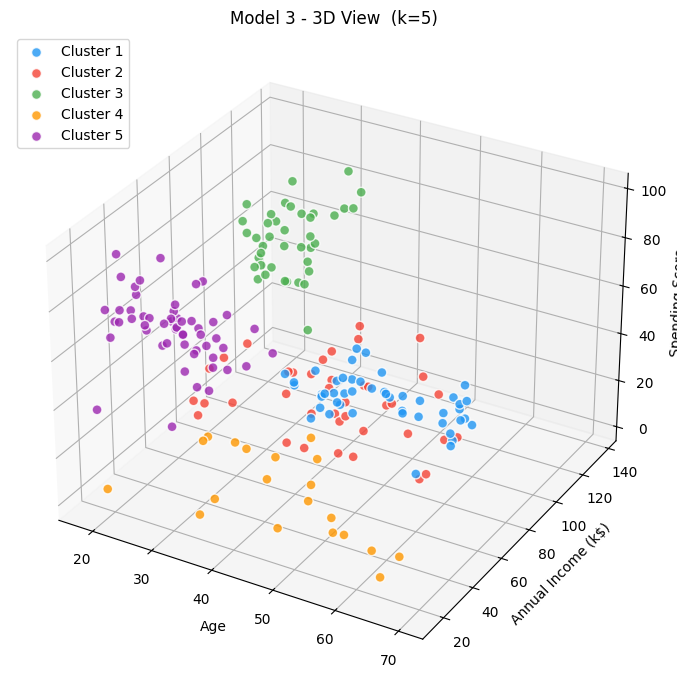

In [12]:
K3 = 5  # optimal k identified from the elbow above

km3 = KMeans(n_clusters=K3, init='k-means++', n_init=10, random_state=RANDOM_SEED)
labels3 = km3.fit_predict(X3)

# 3D scatter plot using original (unscaled) values for readability
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for i in range(K3):
    mask = labels3 == i
    ax.scatter(X3_raw[mask, 0], X3_raw[mask, 1], X3_raw[mask, 2],
               color=PALETTE[i], label=f'Cluster {i+1}',
               alpha=0.8, edgecolors='white', s=50)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title(f'Model 3 - 3D View  (k={K3})')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

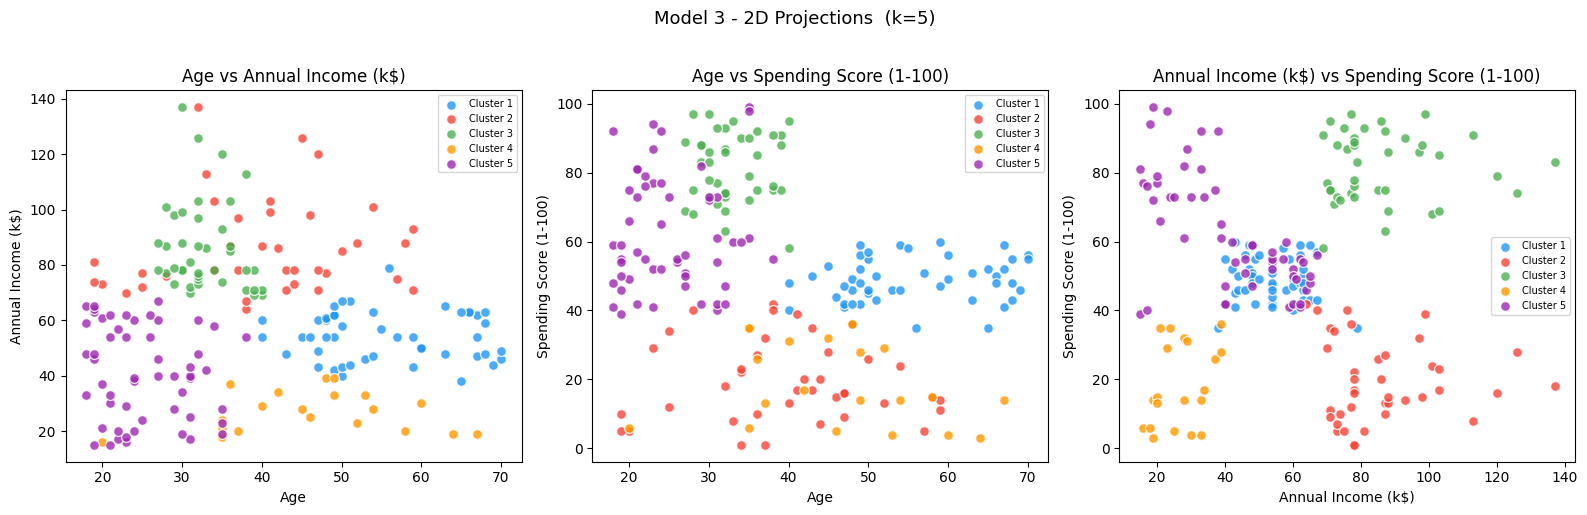

In [13]:
# 2D projections - each subplot shows a different pair of features
pairs = [
    (0, 1, 'Age', 'Annual Income (k$)'),
    (0, 2, 'Age', 'Spending Score (1-100)'),
    (1, 2, 'Annual Income (k$)', 'Spending Score (1-100)')
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (xi, yi, xlabel, ylabel) in zip(axes, pairs):
    for i in range(K3):
        mask = labels3 == i
        ax.scatter(X3_raw[mask, xi], X3_raw[mask, yi],
                   color=PALETTE[i], label=f'Cluster {i+1}',
                   alpha=0.8, edgecolors='white', s=50)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs {ylabel}')
    ax.legend(fontsize=7)
plt.suptitle(f'Model 3 - 2D Projections  (k={K3})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 6 - Customer Segmentation & Export

The cluster labels produced by Model 3 are used to assign each customer to a **Customer Group**. The groups are labelled from 1 upward (offsetting the zero-based K-Means output) to avoid confusion with a missing or null group.

The result is saved to `datasets/mall_customers_prediction.xlsx` with two columns:
- **CustomerID** - the original customer identifier
- **Customer Group** - the assigned cluster (1 to k)

In [14]:
output = pd.DataFrame({
    'CustomerID'     : df['CustomerID'],
    'Customer Group' : labels3 + 1          # shift from 0-based to 1-based labelling
})

output.to_excel('datasets/mall_customers_prediction.xlsx', index=False)
print("Saved to 'datasets/mall_customers_prediction.xlsx'")
print()
print('Group sizes:')
print(output['Customer Group'].value_counts().sort_index())
display(output.head(10))

Saved to 'datasets/mall_customers_prediction.xlsx'

Group sizes:
Customer Group
1    47
2    39
3    40
4    20
5    54
Name: count, dtype: int64


,CustomerID,Customer Group
0,1,5
1,2,5
2,3,4
3,4,5
4,5,5
5,6,5
6,7,4
7,8,5
8,9,4
9,10,5


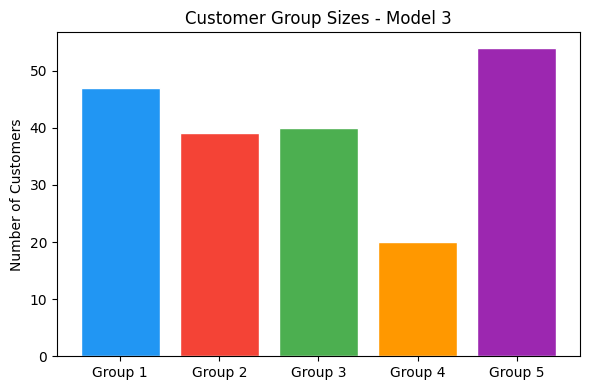

In [15]:
# Bar chart - number of customers per group
counts = output['Customer Group'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([f'Group {g}' for g in counts.index], counts.values,
       color=PALETTE[:K3], edgecolor='white')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Group Sizes - Model 3')
plt.tight_layout()
plt.show()

## Conclusions

| Model | Features | Optimal k | Key insight |
|-------|----------|-----------|-------------|
| Model 1 | Age + Spending Score | 4 | Different age groups exhibit distinct spending patterns |
| Model 2 | Annual Income + Spending Score | 5 | Clear 5-cluster structure - income/spending segments are well separated |
| Model 3 | Age + Annual Income + Spending Score | 5 | Full customer profile; clusters visible across all three dimensions |

**Key takeaways:**

- **The Elbow Method identifies a clear kink in the WCSS curve for each model.** Beyond the optimal k, additional clusters produce only marginal reductions in inertia, confirming that the chosen k captures the main natural groupings without over-segmenting.
- **Model 2 (Income + Spending Score) produces the most visually distinct clusters.** The five groups correspond to well-known customer archetypes: low-income low-spenders, low-income high-spenders, average shoppers, high-income low-spenders, and high-income high-spenders (premium customers).
- **Model 1 (Age + Spending Score) reveals a generational pattern.** Younger customers tend to cluster around high spending scores regardless of income, while older customers concentrate at lower spending scores.
- **Model 3 integrates all three dimensions.** The 3D scatter plot and its 2D projections confirm that the clusters remain well separated when the full feature space is considered. Standardisation is essential here: without it, `Annual Income` (range up to 137) would dominate the Euclidean distance over `Age` (range up to 70) and `Spending Score` (range up to 99).
- **Customer group assignments** from Model 3 are saved to `datasets/mall_customers_prediction.xlsx` and can be used directly for targeted marketing campaigns, loyalty programme tiers, or personalised offers.